# 04. 워크플로 패턴 — 5가지 핵심 패턴

## 학습 목표

Prompt Chaining, Parallelization, Routing, Orchestrator-Worker, Evaluator-Optimizer 패턴을 이해합니다.

## 4.1 환경 설정

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-5.4")

In [2]:
# Observability 설정 (선택) - LangSmith 또는 Langfuse
# .env에 키를 설정하거나, 아래 주석을 해제하여 직접 입력하세요.
# os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-..."
# os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-..."
# os.environ["LANGFUSE_HOST"] = "https://lf.ddok.ai"
import os

# LangSmith: LANGSMITH_TRACING=true 시 자동 활성화 (코드 수정 불필요)
if os.environ.get("LANGSMITH_TRACING", "").lower() == "true":
    os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
    os.environ.setdefault("LANGCHAIN_API_KEY", os.environ.get("LANGSMITH_API_KEY", ""))
    os.environ.setdefault("LANGCHAIN_PROJECT", os.environ.get("LANGSMITH_PROJECT", "default"))
    print(f"LangSmith tracing ON \u2014 project: {os.environ['LANGCHAIN_PROJECT']}")

# Langfuse: invoke/stream 호출 시 config={"callbacks": [langfuse_handler]} 전달
langfuse_handler = None
if os.environ.get("LANGFUSE_SECRET_KEY"):
    from langfuse.langchain import CallbackHandler
    langfuse_handler = CallbackHandler()
    print(f"Langfuse tracing ON \u2014 {os.environ.get('LANGFUSE_HOST', '')}")

# Langfuse config: pass to invoke/stream/batch calls
lf_config = {"callbacks": [langfuse_handler]} if langfuse_handler else {}


Langfuse tracing ON — 


## 4.2 Prompt Chaining — 순차적 LLM 호출

- 각 단계의 출력이 다음 단계의 입력이 됨
- 용도: 번역 → 검증 → 교정, 분석 → 요약 → 포맷팅

![Prompt Chaining](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/prompt_chain.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=762dec147c31b8dc6ebb0857e236fc1f)

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class ChainState(TypedDict):
    topic: str
    draft: str
    improved: str

def generate_draft(state: ChainState) -> dict:
    response = model.invoke(f"다음에 대한 한 문장 사실을 작성해주세요: {state['topic']}", config=lf_config)
    return {"draft": response.content}

def improve_draft(state: ChainState) -> dict:
    response = model.invoke(f"다음 텍스트를 더 매력적으로 개선해주세요: {state['draft']}", config=lf_config)
    return {"improved": response.content}

builder = StateGraph(ChainState)
builder.add_node("draft", generate_draft)
builder.add_node("improve", improve_draft)
builder.add_edge(START, "draft")
builder.add_edge("draft", "improve")
builder.add_edge("improve", END)

chain = builder.compile()
result = chain.invoke({"topic": "Python 프로그래밍"}, config=lf_config)
print(f"초안: {result['draft']}")
print(f"개선: {result['improved']}")

초안: Python은 읽기 쉬운 문법과 다양한 라이브러리를 갖춘 범용 프로그래밍 언어입니다.
개선: 물론입니다. 아래처럼 더 매력적으로 다듬을 수 있습니다:

**Python은 직관적이고 읽기 쉬운 문법, 그리고 풍부한 라이브러리 생태계를 바탕으로 웹 개발, 데이터 분석, 인공지능까지 폭넓게 활용되는 강력한 범용 프로그래밍 언어입니다.**

원하시면 제가 이 문장을  
- **더 짧고 세련되게**
- **광고/홍보 느낌으로**
- **전문적이고 공식적으로**
- **초보자 친화적으로**  
다양한 톤으로도 바꿔드릴 수 있습니다.


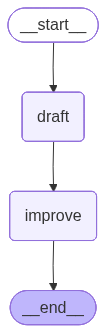

In [4]:
from IPython.display import Image, display

display(Image(chain.get_graph().draw_mermaid_png()))

## 4.3 Parallelization — 독립적 태스크의 동시 실행

![Parallelization](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/parallelization.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=8afe3c427d8cede6fed1e4b2a5107b71)

In [ ]:
from typing import Annotated, TypedDict
import operator


class ParallelState(TypedDict):
    text: str
    # Annotated 하여 결과가 누적되게 만든다.
    analyses: Annotated[list[str], operator.add]


def analyze_tone(state: ParallelState) -> dict:
    r = model.invoke(
        f"한 문장으로 다음의 어조를 설명해주세요: {state['text']}",
        config=lf_config
    )
    return {
        "analyses": [f"어조: {r.content}"]
    }


def analyze_complexity(state: ParallelState) -> dict:
    r = model.invoke(
        f"한 문장으로 다음의 복잡도를 평가해주세요: {state['text']}",
        config=lf_config
    )
    return {
        "analyses": [f"복잡도: {r.content}"]
    }


def synthesize(state: ParallelState) -> dict:
    return {
        "analyses": [
            f"종합: {len(state['analyses'])}개 분석 완료"
        ]
    }


builder = StateGraph(ParallelState)

builder.add_node("tone", analyze_tone)
builder.add_node("complexity", analyze_complexity)
builder.add_node("synthesize", synthesize)

# START에서 두 분석 노드로 병렬 분기
builder.add_edge(START, "tone")
builder.add_edge(START, "complexity")

# 두 노드 완료 후 합성
builder.add_edge("tone", "synthesize")
builder.add_edge("complexity", "synthesize")
builder.add_edge("synthesize", END)

parallel_graph = builder.compile()

result = parallel_graph.invoke(
    {
        "text": "LangGraph는 강력한 에이전트 워크플로를 가능하게 합니다.",
        "analyses": []
    },
    config=lf_config
)

for a in result["analyses"]:
    print(f"  {a}")

  복잡도: 이 문장은 전문 용어(“LangGraph”, “에이전트 워크플로”)가 포함되어 있어 **중간 수준의 복잡도**를 가지며, 관련 배경지식이 없는 독자에게는 다소 추상적으로 느껴질 수 있습니다.
  어조: 간결하고 자신감 있으며, 기술적 가치를 직접적으로 강조하는 홍보성 어조입니다.
  종합: 2개 분석 완료


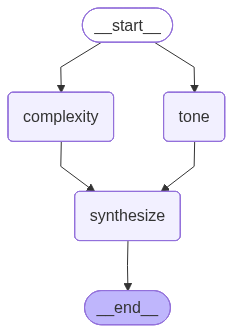

In [16]:
display(Image(parallel_graph.get_graph().draw_mermaid_png()))

## 4.4 Routing — 분류 기반 분기

![Routing](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/routing.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=272e0e9b681b89cd7d35d5c812c50ee6)

In [8]:
from pydantic import BaseModel, Field
from typing import Literal, TypedDict


class Classification(BaseModel):
    category: Literal["technical", "business", "casual"]


class RouteState(TypedDict):
    question: str
    category: str
    answer: str


def classify(state: RouteState) -> dict:
    structured = model.with_structured_output(Classification)
    result = structured.invoke(
        f"다음 질문을 분류하세요: {state['question']}",
        config=lf_config
    )
    return {"category": result.category}


def handle_technical(state: RouteState) -> dict:
    r = model.invoke(
        f"기술 전문가로서 답변해주세요: {state['question']}",
        config=lf_config
    )
    return {"answer": r.content}


def handle_business(state: RouteState) -> dict:
    r = model.invoke(
        f"비즈니스 어드바이저로서 답변해주세요: {state['question']}",
        config=lf_config
    )
    return {"answer": r.content}


def handle_casual(state: RouteState) -> dict:
    r = model.invoke(
        f"가볍게 답변해주세요: {state['question']}",
        config=lf_config
    )
    return {"answer": r.content}


def route(state: RouteState) -> str:
    return state["category"]


builder = StateGraph(RouteState)

builder.add_node("classify", classify)
builder.add_node("technical", handle_technical)
builder.add_node("business", handle_business)
builder.add_node("casual", handle_casual)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route, {
    "technical": "technical",
    "business": "business",
    "casual": "casual",
})

builder.add_edge("technical", END)
builder.add_edge("business", END)
builder.add_edge("casual", END)

router = builder.compile()

result = router.invoke(
    {
        #"question": "Python에서 가비지 컬렉션은 어떻게 작동하나요?"
        "question": "한국의 세법의 변경 Risk는 국세청 사이트에서 확인 가능한가요?"
    },
    config=lf_config
)

print(f"카테고리: {result['category']}")
print(f"답변: {result['answer'][:200]}")

Failed to detach context
Traceback (most recent call last):
  File "/home/kmkang/posco-dx-agent-dev-day2/.venv/lib/python3.12/site-packages/langfuse/_client/propagation.py", line 272, in _propagate_attributes
    yield
GeneratorExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/kmkang/posco-dx-agent-dev-day2/.venv/lib/python3.12/site-packages/opentelemetry/context/__init__.py", line 155, in detach
    _RUNTIME_CONTEXT.detach(token)
  File "/home/kmkang/posco-dx-agent-dev-day2/.venv/lib/python3.12/site-packages/opentelemetry/context/contextvars_context.py", line 53, in detach
    self._current_context.reset(token)
ValueError: <Token var=<ContextVar name='current_context' default={} at 0x76c0e1331260> at 0x76c0e0157e00> was created in a different Context
Propagated attribute 'metadata.langgraph_step' value is not a string. Dropping value.
Propagated attribute 'metadata.langgraph_triggers' value is not a string. Drop

카테고리: business
답변: 네, **일정 부분은 국세청 사이트에서 확인 가능합니다.** 다만 **“세법 변경 리스크”를 국세청 사이트 하나만으로 완전히 파악하기는 어렵고**, 보통은 **국세청 + 기획재정부 + 국회 입법예고/법령정보**를 함께 봐야 합니다.

핵심만 말씀드리면:

## 1) 국세청 사이트에서 확인 가능한 것
국세청 홈페이지에서는 주로 아래 내용을 확인할 수 있습니다


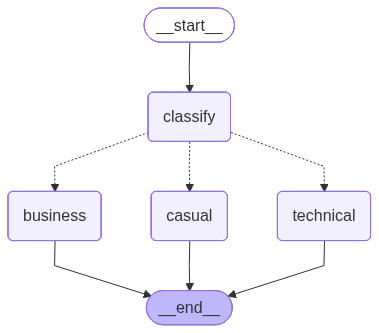

In [18]:
display(Image(router.get_graph().draw_mermaid_png()))

## 4.5 Orchestrator-Worker — Send()로 동적 워커 생성

![Orchestrator-Worker](https://mintcdn.com/langchain-5e9cc07a/ybiAaBfoBvFquMDz/oss/images/worker.png?fit=max&auto=format&n=ybiAaBfoBvFquMDz&q=85&s=2e423c67cd4f12e049cea9c169ff0676)

In [17]:
from langgraph.types import Send
from typing import Annotated, TypedDict
import operator


class OrchestratorState(TypedDict):
    topic: str
    sections: list[str]
    results: Annotated[list[str], operator.add]


class WorkerState(TypedDict):
    section: str


def plan_sections(state: OrchestratorState) -> dict:
    r = model.invoke(
        #f"'{state['topic']}'에 대한 기사의 짧은 섹션 제목 3개를 나열해주세요. 한 줄에 하나씩, 번호 없이.",
        f"'{state['topic']}'에 대한 기사의 짧은 섹션 제목들을 나열해주세요. 한 줄에 하나씩, 스스로 판단해서 적절한 제목의 갯수 설정 단 10개가 넘지 않도록.",
        config=lf_config
    )

    sections = [
        s.strip()
        for s in r.content.strip().split("\n")
        if s.strip()
    #][:3] # 최대 3개 섹션으로 제한
    ]
    #[:10]

    return {"sections": sections}


def assign_workers(state: OrchestratorState) -> list[Send]:
    return [
        Send("worker", {"section": s})
        for s in state["sections"]
    ]


def worker(state: WorkerState) -> dict:
    r = model.invoke(
        f"다음에 대해 한 문장으로 작성해주세요: {state['section']}",
        config=lf_config
    )

    return {
        "results": [
            f"## {state['section']}\n{r.content}"
        ]
    }


builder = StateGraph(OrchestratorState)

builder.add_node("plan", plan_sections)
builder.add_node("worker", worker)

builder.add_edge(START, "plan")

builder.add_conditional_edges(
    "plan",
    assign_workers,
    ["worker"]
)

builder.add_edge("worker", END)

orchestrator = builder.compile()

result = orchestrator.invoke(
    {
        "topic": "머신러닝",
        "sections": [],
        "results": []
    },
    config=lf_config
)

for r in result["results"]:
    print(r)
    print()

## 머신러닝이란 무엇인가
머신러닝은 컴퓨터가 명시적인 규칙을 일일이 프로그래밍하지 않아도 데이터로부터 패턴을 학습해 예측이나 판단을 수행하도록 하는 인공지능 기술입니다.

## 머신러닝의 핵심 원리
머신러닝의 핵심 원리는 컴퓨터가 명시적으로 규칙을 일일이 프로그래밍하지 않아도 데이터를 통해 패턴을 학습하고, 이를 바탕으로 새로운 입력에 대해 예측하거나 판단하는 데 있습니다.

## 지도학습과 비지도학습
지도학습은 정답이 있는 데이터를 학습해 예측이나 분류를 수행하는 방법이고, 비지도학습은 정답이 없는 데이터에서 숨겨진 패턴이나 구조를 스스로 찾아내는 방법입니다.

## 데이터가 성능을 좌우한다
데이터의 품질과 양은 모델의 학습 결과와 최종 성능을 결정짓는 핵심 요소다.

## 알고리즘의 종류와 특징
알고리즘은 문제를 해결하기 위한 절차적 방법으로, 대표적으로 완전탐색, 분할정복, 탐욕법, 동적 계획법, 백트래킹 등이 있으며 각각 모든 경우를 탐색하거나, 문제를 나누어 해결하거나, 최적 선택을 반복하거나, 중복 계산을 줄이거나, 해를 찾다가 조건에 맞지 않으면 되돌아가는 특징을 가진다.

## 머신러닝의 실제 활용 사례
머신러닝은 의료 영상 진단, 개인화 추천, 금융 이상 거래 탐지, 자율주행, 고객 상담 챗봇 등 다양한 분야에서 데이터를 학습해 예측과 의사결정을 자동화하는 데 실제로 활용되고 있습니다.

## 정확도와 한계 이해하기
정확도와 한계를 이해한다는 것은 결과가 얼마나 실제와 일치하는지 평가하는 동시에, 적용 범위와 오류 가능성을 함께 파악하는 것을 의미합니다.

## 딥러닝과의 차이점
머신러닝은 사람이 특징을 설계하고 이를 바탕으로 학습하는 경우가 많은 반면, 딥러닝은 인공신경망을 이용해 데이터로부터 특징을 스스로 추출하며 더 복잡한 패턴을 학습하는 방식이라는 점에서 차이가 있습니다.

## 윤리와 편향 문제
윤리와 편향 문제는 인공지능이 데이터를 학습하고 의사결정을 수행하는 과정에서 특정 집단에 불공정한 결과를 초래하거나 사회적 가치와 책임을 훼

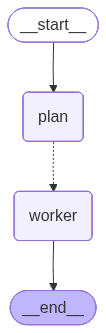

In [10]:
display(Image(orchestrator.get_graph().draw_mermaid_png()))

## 4.6 Evaluator-Optimizer — 생성-평가 반복 루프

![Evaluator-Optimizer](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/evaluator_optimizer.png?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=9bd0474f42b6040b14ed6968a9ab4e3c)

In [19]:
class EvalState(TypedDict):
    task: str
    draft: str
    feedback: str
    is_good: bool
    iterations: int

def generate(state: EvalState) -> dict:
    if state.get("feedback"):
        prompt = f"피드백을 반영하여 개선해주세요.\n원본: {state['draft']}\n피드백: {state['feedback']}"
    else:
        prompt = f"다음에 대한 한 문장 슬로건을 작성해주세요: {state['task']}"
    r = model.invoke(prompt, config=lf_config)
    return {"draft": r.content, "iterations": state.get("iterations", 0) + 1}

def evaluate(state: EvalState) -> dict:
    r = model.invoke(f"이 슬로건을 창의성을 기준으로 1-10으로 평가하고 간단한 피드백을 주세요: '{state['draft']}'", config=lf_config)
    content = r.content
    is_good = any(f"{n}/10" in content for n in range(8, 11))
    return {"feedback": content, "is_good": is_good}

def should_retry(state: EvalState) -> str:
    #if state["is_good"] or state["iterations"] >= 3:
    #한번에 통과하지 않고, 3번이상 시도해서 반환되는 케이스를 강제로 만들고 실행하도록 변경함 KKM
    if state["iterations"] >= 3:
        return END
    return "generate"

builder = StateGraph(EvalState)
builder.add_node("generate", generate)
builder.add_node("evaluate", evaluate)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")
builder.add_conditional_edges("evaluate", should_retry, ["generate", END])

optimizer = builder.compile()
result = optimizer.invoke({"task": "Python 학습 플랫폼"}, config=lf_config)
print(f"최종 초안 ({result['iterations']}번 반복 후): {result['draft']}")

최종 초안 (3번 반복 후): 물론입니다. 피드백을 반영해, 이번에는 **익숙한 교육 문법에서 조금 더 벗어나고**,  
**표현의 결을 더 신선하게 살린 방향**으로 개선해보겠습니다.

핵심은 다음 3가지입니다.  
- **“배움 → 실전”의 뻔한 연결어를 줄이기**
- **첫걸음/성장/자신감** 같은 상투어 대신 **장면이 그려지는 표현** 쓰기
- 비슷한 구조 반복보다 **한 줄 한 줄의 캐릭터를 분명히 만들기**

## 개선안
**Python, 배우는 순간보다 써먹는 순간이 길어지도록.**

## 창의성 점수 높은 버전 10개
1. **Python은 외우는 게 아니라, 자꾸 써보게 되는 거니까**
2. **문법을 넘기면, Python은 곧 도구가 됩니다**
3. **배운 코드가 멈추지 않도록, 바로 움직이는 Python**
4. **Python을 공부하는 시간보다, 다루는 시간이 많아지게**
5. **한 줄씩 익히다 보면, 어느새 만들고 있는 Python**
6. **처음 친 코드가, 끝내 내 일이 되는 Python**
7. **Python, 아는 것에서 끝나지 않게**
8. **손에 익는 Python은, 결국 써먹게 됩니다**
9. **배운 문법이 화면 밖에서도 일하게**
10. **Python을 배우는 법보다, Python을 쓰는 감각으로**

## 조금 더 인상적으로 밀어붙인 버전
좀 더 카피다운 느낌, 더 기억에 남는 톤으로 가면:

1. **Python은 배운 날보다, 써먹는 날이 더 많아야 하니까**
2. **문법 뒤에 숨지 않는 Python**
3. **공부한 코드 말고, 움직이는 코드**
4. **Python, 알게 되는 순간보다 다루게 되는 순간까지**
5. **손끝에서 바로 일하는 Python**
6. **익히는 Python에서, 부리는 Python으로**
7. **코드는 머리에 남기지 말고, 손에 남기세요**
8. **배운 만큼이 아니라, 만든 만큼 내 것이 되는 Python**
9. **Python을 공부했다는 말보다, Python

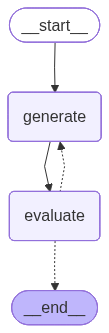

In [22]:
display(Image(optimizer.get_graph().draw_mermaid_png()))

## 4.7 패턴 비교표

| 패턴 | 결정적 | 병렬 | 반복 | 적합 상황 |
|------|--------|------|------|----------|
| Prompt Chaining | O | X | 순차 | 단계별 변환 |
| Parallelization | O | O | X | 독립 분석 |
| Routing | O | X | X | 분류 기반 처리 |
| Orchestrator-Worker | O | O | X | 동적 하위 작업 |
| Evaluator-Optimizer | X | X | O | 품질 개선 루프 |